#### **Setup, Imports, and Data Loading**

In [30]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os

# Load master analytical dataset
processed_path = '../data/processed/master_analytical_view.csv'
df_master = pd.read_csv(processed_path)

print(f"Loaded master analytical dataset with shape: {df_master.shape}")
display(df_master.head())

Loaded master analytical dataset with shape: (4196, 28)


,order_id,agent_id,order_date,breed_type,quantity_ordered,batch_id,region,zone,woreda,agent_tier,...,delivery_dt,initial_brooding_count,surviving_count,mortality_rate_pct,vaccination_compliance_pct,order_value_etb,days_sales_outstanding,overdue_balance_etb,support_tickets_logged,field_visits_count
0,ORD-000007,AGT-0002,2025-08-03,SASSO (Dual-Purpose),100.0,BATCH-202508-128,Central Ethiopia,Silte,Kibet,Silver,...,2025-08-05,100.0,91.0,9.00,80.0,4500.0,5.0,0.0,2.0,2.0
1,ORD-000008,AGT-0002,2025-08-06,SASSO (Dual-Purpose),100.0,BATCH-202508-669,Central Ethiopia,Silte,Kibet,Silver,...,2025-08-09,100.0,94.0,6.00,81.0,4500.0,31.0,4500.0,0.0,1.0
2,ORD-000009,AGT-0002,2025-08-07,SASSO (Dual-Purpose),200.0,BATCH-202508-444,Central Ethiopia,Silte,Kibet,Silver,...,2025-08-09,200.0,190.0,5.00,99.0,9000.0,6.0,0.0,0.0,0.0
3,ORD-000010,AGT-0002,2025-06-15,Bovans Brown (Layer),100.0,BATCH-202506-768,Central Ethiopia,Silte,Kibet,Silver,...,2025-06-17,100.0,93.0,7.00,86.0,4500.0,26.0,0.0,0.0,0.0
4,ORD-000011,AGT-0002,2025-05-28,SASSO (Dual-Purpose),300.0,BATCH-202505-513,Central Ethiopia,Silte,Kibet,Silver,...,2025-05-30,300.0,280.0,6.67,89.0,13500.0,17.0,0.0,0.0,0.0


#### **Prepare modeling data by dropping missing values and fit an OLS regression model to evaluate mortality determinants**

In [ ]:
model_data = df_master.dropna(subset=[
    'mortality_rate_pct', 
    'vaccination_compliance_pct', 
    'agent_tier', 
    'region', 
    'quantity_ordered'
]).copy()

# Fit OLS regression model
formula = 'mortality_rate_pct ~ vaccination_compliance_pct + C(agent_tier) + C(region) + quantity_ordered'
model = smf.ols(formula, data=model_data).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     mortality_rate_pct   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     547.7
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:17:17   Log-Likelihood:                -8656.7
No. Observations:                4095   AIC:                         1.734e+04
Df Residuals:                    4084   BIC:                         1.740e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

#### **Prepare features and target, scale continuous variables, and fit an L2-regularized logistic regression model to calculate odds ratios**

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Create binary target variable for high mortality risk (> 10%)
model_data['high_mortality'] = (model_data['mortality_rate_pct'] > 10).astype(int)

# Define feature matrix X and target y with one-hot encoding for categorical variables
X = pd.get_dummies(model_data[['agent_tier', 'region', 'vaccination_compliance_pct', 'quantity_ordered']], drop_first=True)
y = model_data['high_mortality']

# Scale continuous features
scaler = StandardScaler()
X_scaled = X.copy()
cont_cols = ['vaccination_compliance_pct', 'quantity_ordered']
X_scaled[cont_cols] = scaler.fit_transform(X[cont_cols])

# Fit L2-regularized Logistic Regression to resolve complete separation in the Gold tier
l2_logit = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
l2_logit.fit(X_scaled, y)

# Compile results into a summary DataFrame with Odds Ratios
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': l2_logit.coef_[0],
    'Odds_Ratio': np.exp(l2_logit.coef_[0])
})
print("--- L2-Regularized Logistic Regression Results ---")
print(coef_df.to_string(index=False))

c:\Users\tohiba\Desktop\ethio_chicken_analytics2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


--- L2-Regularized Logistic Regression Results ---
                   Feature  Coefficient  Odds_Ratio
vaccination_compliance_pct    -0.087816    0.915930
          quantity_ordered     0.156667    1.169606
           agent_tier_Gold    -1.839203    0.158944
            agent_tier_New     5.174537  176.714799
         agent_tier_Silver     0.157453    1.170526
   region_Central Ethiopia     0.066604    1.068872
             region_Oromia     0.335198    1.398217
             region_Sidama     0.380801    1.463457
     region_South Ethiopia     0.023895    1.024182
             region_Tigray     0.239272    1.270323


In [21]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = l2_logit.predict(X)
y_prob = l2_logit.predict_proba(X)[:, 1]

auc_score = roc_auc_score(y, y_prob)
print(f"ROC-AUC Score: {auc_score:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y, y_pred))
print("--- Confusion Matrix ---")
print(confusion_matrix(y, y_pred))

ROC-AUC Score: 0.6423

--- Classification Report ---


c:\Users\tohiba\Desktop\ethio_chicken_analytics2\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tohiba\Desktop\ethio_chicken_analytics2\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tohiba\Desktop\ethio_chicken_analytics2\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3623
           1       0.12      1.00      0.21       472

    accuracy                           0.12      4095
   macro avg       0.06      0.50      0.10      4095
weighted avg       0.01      0.12      0.02      4095

--- Confusion Matrix ---
[[   0 3623]
 [   0  472]]


#### **Evaluate L2 Logistic Regression performance using ROC-AUC, classification report, and confusion matrix**

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Separate numeric and categorical features
numeric_features = ['vaccination_compliance_pct', 'quantity_ordered']
categorical_features = [c for c in X.columns if c not in numeric_features]

# Rebuild X and y cleanly with scaling
X_raw = model_data[['vaccination_compliance_pct', 'quantity_ordered', 'agent_tier', 'region']].copy()
X_encoded = pd.get_dummies(X_raw, drop_first=True)
y_target = model_data['high_mortality']

scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

# Fit L2 Logistic Regression with balanced class weights
balanced_logit = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', max_iter=1000)
balanced_logit.fit(X_scaled, y_target)

y_prob_bal = balanced_logit.predict_proba(X_scaled)[:, 1]
y_pred_bal = balanced_logit.predict(X_scaled)

print(f"ROC-AUC Score: {roc_auc_score(y_target, y_prob_bal):.4f}")
print("\n--- Balanced Classification Report ---")
print(classification_report(y_target, y_pred_bal))
print("--- Confusion Matrix ---")
print(confusion_matrix(y_target, y_pred_bal))

c:\Users\tohiba\Desktop\ethio_chicken_analytics2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


ROC-AUC Score: 0.9411

--- Balanced Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      3623
           1       0.81      0.87      0.84       472

    accuracy                           0.96      4095
   macro avg       0.89      0.92      0.91      4095
weighted avg       0.96      0.96      0.96      4095

--- Confusion Matrix ---
[[3524   99]
 [  61  411]]


#### **Extract coefficients and Odds Ratios from the balanced L2 model**

In [ ]:
feature_names = X_scaled.columns
coefs = balanced_logit.coef_[0]
odds_ratios = np.exp(coefs)

results_balanced = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    'Odds_Ratio': odds_ratios
}).sort_values(by='Odds_Ratio', ascending=False)

print("--- Balanced L2 Logistic Regression Feature Weights & Odds Ratios ---")
print(results_balanced.to_string(index=False))

--- Balanced L2 Logistic Regression Feature Weights & Odds Ratios ---
                   Feature  Coefficient  Odds_Ratio
            agent_tier_New     5.416436  225.075524
         agent_tier_Silver     0.268962    1.308605
          quantity_ordered     0.189375    1.208494
             region_Sidama     0.073499    1.076268
vaccination_compliance_pct    -0.006719    0.993304
             region_Oromia    -0.015968    0.984158
     region_South Ethiopia    -0.031204    0.969278
             region_Tigray    -0.081124    0.922079
   region_Central Ethiopia    -0.355844    0.700582
           agent_tier_Gold    -2.662848    0.069749


#### **Train XGBoost classifier with class weighting and extract feature importances**

In [24]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_target, test_size=0.2, random_state=42, stratify=y_target)

xgb_model = xgb.XGBClassifier(scale_pos_weight=3.6, eval_metric='auc', random_state=42)
xgb_model.fit(X_train, y_train)

importances = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- XGBoost Feature Importances ---")
print(importances.to_string(index=False))

--- XGBoost Feature Importances ---
                   Feature  Importance
            agent_tier_New    0.882981
           agent_tier_Gold    0.048030
         agent_tier_Silver    0.013696
             region_Sidama    0.009678
     region_South Ethiopia    0.008516
vaccination_compliance_pct    0.008138
             region_Oromia    0.007952
          quantity_ordered    0.007665
   region_Central Ethiopia    0.007019
             region_Tigray    0.006326


#### **Calculate predicted probabilities from the balanced logistic regression model and summarize risk by agent tier**

In [25]:
# Compute predicted high-mortality probability across agent tiers
model_data['pred_prob_balanced'] = balanced_logit.predict_proba(X_scaled)[:, 1]

risk_summary = model_data.groupby('agent_tier').agg(
    total_orders=('order_id', 'count'),
    actual_high_mortality_rate=('high_mortality', 'mean'),
    mean_predicted_prob=('pred_prob_balanced', 'mean')
).reset_index()

print("--- Operational Risk Summary by Agent Tier ---")
print(risk_summary.to_string(index=False))

--- Operational Risk Summary by Agent Tier ---
agent_tier  total_orders  actual_high_mortality_rate  mean_predicted_prob
    Bronze          1554                    0.017375             0.121559
      Gold           548                    0.000000             0.009467
       New           510                    0.805882             0.966643
    Silver          1483                    0.022927             0.150282


In [26]:
new_tier_breakdown = model_data[model_data['agent_tier'] == 'New'].groupby('region').agg(
    new_agent_orders=('order_id', 'count'),
    actual_high_mortality_rate=('high_mortality', 'mean'),
    mean_quantity_ordered=('quantity_ordered', 'mean'),
    mean_vaccination_compliance=('vaccination_compliance_pct', 'mean')
).reset_index().sort_values(by='new_agent_orders', ascending=False)

print("--- New Tier Risk Breakdown by Region ---")
print(new_tier_breakdown.to_string(index=False))

--- New Tier Risk Breakdown by Region ---
          region  new_agent_orders  actual_high_mortality_rate  mean_quantity_ordered  mean_vaccination_compliance
          Oromia               125                    0.848000             276.800000                    68.960000
Central Ethiopia               115                    0.808696             283.478261                    70.104348
          Tigray                91                    0.824176             272.527473                    71.318681
          Amhara                86                    0.720930             310.465116                    70.813953
          Sidama                49                    0.877551             251.020408                    68.571429
  South Ethiopia                44                    0.727273             277.272727                    71.000000


#### **Generate, display, and save the bar plot for average chick mortality rate by agent tier with a 10% risk threshold line**

C:\Users\tohiba\AppData\Local\Temp\ipykernel_8872\4051189488.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


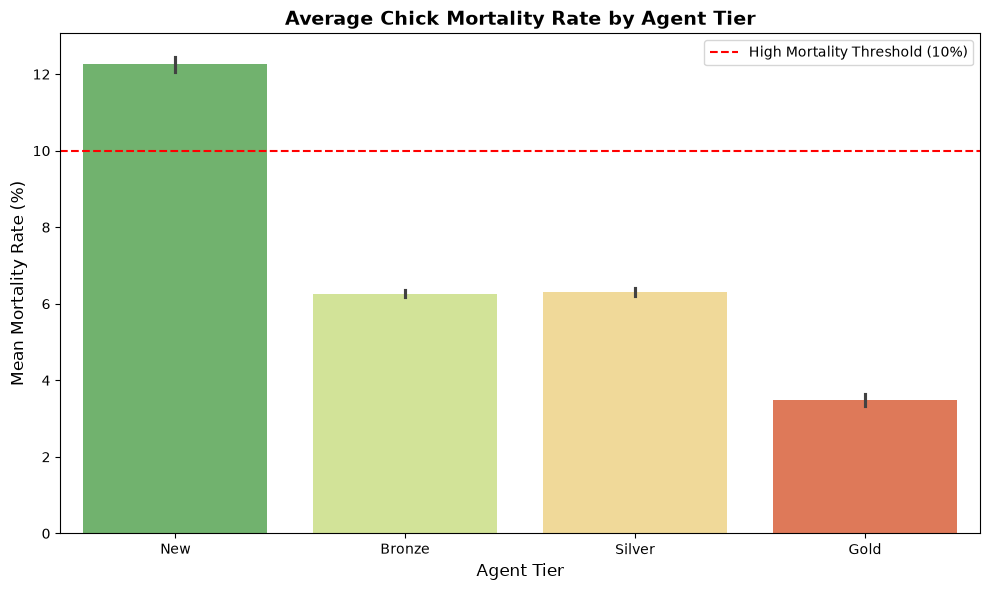

Saved figure to ../outputs/figures/average_chick_mortality_rate_by_agent_tier.png


In [27]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure output directory exists
os.makedirs('../outputs/figures', exist_ok=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=model_data, 
    x='agent_tier', 
    y='mortality_rate_pct', 
    order=['New', 'Bronze', 'Silver', 'Gold'],
    palette='RdYlGn_r'
)
plt.axhline(10, color='red', linestyle='--', label='High Mortality Threshold (10%)')
plt.title('Average Chick Mortality Rate by Agent Tier', fontsize=14, fontweight='bold')
plt.xlabel('Agent Tier', fontsize=12)
plt.ylabel('Mean Mortality Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()

# Save high-resolution figure
fig_path = '../outputs/figures/average_chick_mortality_rate_by_agent_tier.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure to {fig_path}")

#### **Perform One-way ANOVA and Kruskal-Wallis tests to evaluate mortality rate differences across agent tiers**

In [28]:
import scipy.stats as stats

# Group mortality rates by agent tier
tiers = ['New', 'Bronze', 'Silver', 'Gold']
groups = [model_data[model_data['agent_tier'] == tier]['mortality_rate_pct'].dropna() for tier in tiers]

# One-way ANOVA
f_stat, p_val_anova = stats.f_oneway(*groups)
print(f"One-way ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val_anova:.4e}")

# Kruskal-Wallis non-parametric test (handles skew and zero-mortality Gold tier)
kw_stat, p_val_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-statistic: {kw_stat:.4f}, p-value: {p_val_kw:.4e}")

One-way ANOVA F-statistic: 1813.8651, p-value: 0.0000e+00
Kruskal-Wallis H-statistic: 1734.4996, p-value: 0.0000e+00


#### **Save the scored dataset containing model predictions and risk flags to CSV for downstream operational dashboards**

In [ ]:
output_path = '../data/processed/mortality_analysis_scored.csv'
model_data.to_csv(output_path, index=False)
print(f"Saved scored analytical dataset to {output_path}")

Saved scored analytical dataset to ../data/processed/mortality_analysis_scored.csv
